In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import lss_utils
import PT_field

if jax.config.jax_enable_x64:
    print("Using 64-bit precision.")
    base_dtype = jnp.float64
else:
    print("Using 32-bit precision.")
    base_dtype = jnp.float32


Using 64-bit precision.


In [2]:
boxsize = 160.0
kf = 2 * jnp.pi / boxsize
z_ic = 99
z_out = 2.8
OM0 = 0.308

growth = PT_field.growth_D_f(z_out, OM0)[0] / PT_field.growth_D_f(z_ic, OM0)[0]
growth_f = PT_field.growth_D_f(z_out, OM0)[1]
print(growth, growth_f)

### Load the initial conditions and Lyman-alpha field from an appropriate source
root = '/home/akitsukz/works/LyA_field/sherwood'
#ics_r = np.load(f'{root}/ics_field_r.npy')
#lya_r = np.load(f'{root}/lyA_field_r.npy')

ics_r = np.load(f'{root}/data_forKaz_L160_N256/Sherwood_ics_L160_Nmesh256_z2.8.npy')
lya_r = np.load(f'{root}/data_forKaz_L160_N256/Sherwood_deltaflux_L160_Nmesh256_z2.8.npy')

ng = ics_r.shape[0]
print(ng)

ics_k = jnp.fft.rfftn(ics_r, norm='forward') * growth
lya_k = jnp.fft.rfftn(lya_r, norm='forward')

ics_k = ics_k.at[0,0,0].set(0.0)
lya_k = lya_k.at[0,0,0].set(0.0)

26.1238338294402 0.9783375788168764
256


In [ ]:
### define the k-bin for measurements
kmax = 5.02
n_bins = int((kmax - kf)/(kf))
print(n_bins)
k_edges = jnp.linspace(kf, kmax, n_bins)

mu_min = 0.
mu_max = 1.0

measure_pk = lss_utils.Measure_Pk(boxsize, ng, k_edges, dtype=base_dtype)
pk_ic = measure_pk(ics_k, mu_min=mu_min, mu_max=mu_max)
pk_lya = measure_pk(lya_k, mu_min=mu_min, mu_max=mu_max)
pk_cross = measure_pk(ics_k, lya_k, mu_min=mu_min, mu_max=mu_max)

126


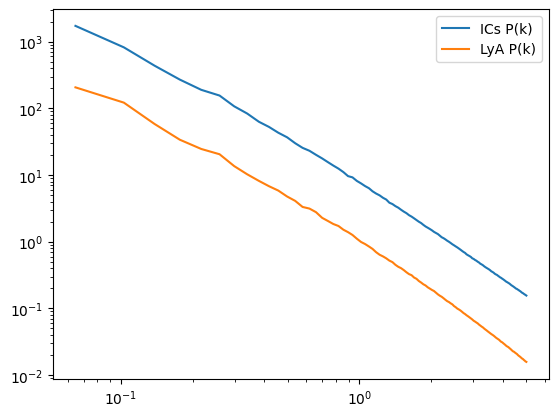

In [4]:
plt.plot(pk_ic[:,0], pk_ic[:,1], label='ICs P(k)')
plt.plot(pk_lya[:,0], pk_lya[:,1], label='LyA P(k)')
plt.legend()
plt.xscale('log')
plt.yscale('log')

In [ ]:
ng_pad = int(2.0*ng)
ng_L = int(1.5*ng)
ng_E = ng
window_order = 2
interlace = True

model = PT_field.LPT_Forward(boxsize=boxsize, ng=ng, ng_pad=ng_pad, ng_L=ng_L, ng_E=ng_E, 
                             mas_cfg=(window_order, interlace), 
                             rsd=True, lya=True, lya_full_fields=True, lpt_order=1,
                             dtype=base_dtype,
                             )

shifted_fields = model.get_shifted_fields(ics_k, growth_f=growth_f)

idx_to_fields = {0:'dz', 1:'d1', 2:'d2', 3:'dG2', 4:'dG2par', 5:'deta2', 6:'ddeta', 7:'dKKpar', 8:'dPi2par', 9:'d3'}


In [ ]:
#mu_edges = jnp.array([0.0, 0.25, 0.5, 0.75, 1.0])
#mu_edges = jnp.array([0.0, 0.33, 0.66, 1.0])
mu_edges = jnp.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

#idx_to_mu = {0: r'$\mu\in [0.0, 0.33]$', 
#             1: r'$\mu\in [0.3, 0.66]$',
#             2: r'$\mu\in [0.66, 1.0]$',
#             }


#idx_to_mu = {0: r'$\mu\in [0, 0.25]$', 
#             1: r'$\mu\in [0.25, 0.5]$',
#             2: r'$\mu\in [0.5, 0.75]$',
#             3: r'$\mu\in [0.75, 1]$',
#             }

idx_to_mu = {0: r'$\mu\in [0, 0.1]$', 
             1: r'$\mu\in [0.1, 0.2]$',
             2: r'$\mu\in [0.2, 0.3]$',
             3: r'$\mu\in [0.3, 0.4]$',
             4: r'$\mu\in [0.4, 0.5]$',
             5: r'$\mu\in [0.5, 0.6]$',
             6: r'$\mu\in [0.6, 0.7]$',
             7: r'$\mu\in [0.7, 0.8]$',
             8: r'$\mu\in [0.8, 0.9]$',
             9: r'$\mu\in [0.9, 1.0]$',
             }


#remove_idx = jnp.array([1,])
#mask = ~jnp.isin(jnp.arange(k_edges.shape[0]), remove_idx)
#k_edges = k_edges[mask]

measure_pk_E = lss_utils.Measure_Pk(boxsize, ng_E, k_edges, dtype=base_dtype)

k_arr, pks_auto, Nmodes = PT_field.compute_pks_2d(shifted_fields, mu_edges, measure_pk=measure_pk_E)

#pks_auto: (n_fields, Nk, Nmu)

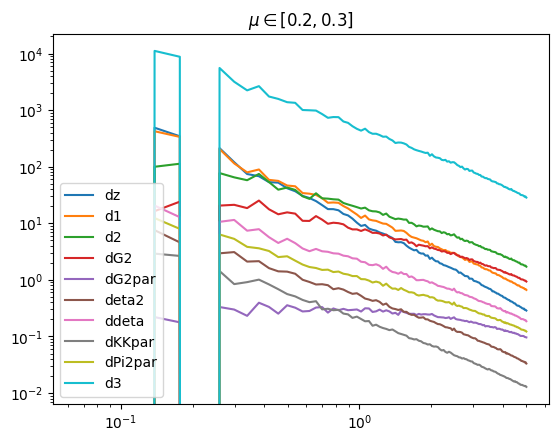

In [7]:
i_field = 0
i_mu = 2
mu = idx_to_mu[i_mu]
for i_field in range(len(shifted_fields)):
    field = idx_to_fields[i_field]
    plt.plot(k_arr, pks_auto[i_field,:,i_mu], label=f'{field}')

plt.title(mu)
plt.legend()
plt.xscale('log')
plt.yscale('log')

In [ ]:
#lya_fields = model.to_lya_fields(shifted_fields, growth_f=growth_f)

lya_fields = jnp.array([shifted_fields[1], ### d1
                        shifted_fields[2], ### d2
                        shifted_fields[3], ### G2
                        shifted_fields[9], ### d3
                        shifted_fields[7], ### KKpar
                        shifted_fields[0] - growth_f*shifted_fields[4], ### eta_new
                        shifted_fields[5], ### eta2
                        shifted_fields[6], ### deta
                        shifted_fields[8], ### pi2_par
                        ])

orthogonalized_fields = PT_field.orthogonalize(lya_fields[:-1], 
                                               boxsize=boxsize,
                                               k_edges=k_edges, mu_edges=mu_edges,
                                               measure_pk=measure_pk_E,
                                               jitter=0.0,
                                               dtype=base_dtype,
                                               )

idx_to_lya_full_fields = {0:'d1', 1:'d2', 2:'G2', 3:'d3', 4:'KKpar', 5:'Eta', 6:'Eta2', 7:'dEta', 8:'Pi2par'}

idx_to_ortho_fields = {0:'d1', 1:'d2', 2:'G2', 3:'d3', 4:'KKpar', 5:'Eta', 6:'Eta2', 7:'dEta',}

[orthogonalize] WARNING: 19 low-stat bins (N_modes <= Nmin=5).
  (k_idx=0, mu_idx=1)  k_mean=0.064685, mu_mean=0.150392
  (k_idx=0, mu_idx=2)  k_mean=0.064685, mu_mean=0.250691
  (k_idx=0, mu_idx=3)  k_mean=0.064685, mu_mean=0.351001
  (k_idx=0, mu_idx=4)  k_mean=0.064685, mu_mean=0.451408
  (k_idx=0, mu_idx=6)  k_mean=0.064685, mu_mean=0.650255
  (k_idx=0, mu_idx=8)  k_mean=0.064685, mu_mean=0.847067
  (k_idx=0, mu_idx=9)  k_mean=0.064685, mu_mean=0.947374
  (k_idx=1, mu_idx=1)  k_mean=0.103147, mu_mean=0.150392
  (k_idx=1, mu_idx=2)  k_mean=0.103147, mu_mean=0.250691
  (k_idx=1, mu_idx=5)  k_mean=0.103147, mu_mean=0.551957
  (k_idx=1, mu_idx=9)  k_mean=0.103147, mu_mean=0.947374
  (k_idx=2, mu_idx=1)  k_mean=0.138716, mu_mean=0.150392
  (k_idx=2, mu_idx=4)  k_mean=0.138716, mu_mean=0.451408
  (k_idx=2, mu_idx=6)  k_mean=0.138716, mu_mean=0.650255
  (k_idx=2, mu_idx=7)  k_mean=0.138716, mu_mean=0.746687
  (k_idx=3, mu_idx=1)  k_mean=0.176973, mu_mean=0.150392
  (k_idx=3, mu_idx=3)  k_

### check orthogonalization

In [9]:
k_arr, rij = PT_field.compute_corr_2d(orthogonalized_fields, mu_edges, measure_pk=measure_pk_E)
PT_field.check_max_rij(rij)

0
01  max|r_ij| = 1.213e-15
02  max|r_ij| = 3.795e-15
03  max|r_ij| = 4.626e-15
04  max|r_ij| = 4.274e-15
05  max|r_ij| = 4.251e-14
06  max|r_ij| = 6.250e-15
07  max|r_ij| = 1.386e-14
12  max|r_ij| = 5.026e-15
13  max|r_ij| = 7.685e-15
14  max|r_ij| = 5.066e-15
15  max|r_ij| = 2.367e-14
16  max|r_ij| = 5.335e-15
17  max|r_ij| = 2.089e-14
23  max|r_ij| = 2.373e-14
24  max|r_ij| = 3.024e-14
25  max|r_ij| = 2.028e-14
26  max|r_ij| = 8.012e-15
27  max|r_ij| = 3.193e-14
34  max|r_ij| = 5.465e-14
35  max|r_ij| = 1.062e-12
36  max|r_ij| = 9.511e-14
37  max|r_ij| = 1.089e-13
45  max|r_ij| = 1.073e-13
46  max|r_ij| = 1.468e-14
47  max|r_ij| = 6.186e-14
56  max|r_ij| = 9.173e-13
57  max|r_ij| = 1.962e-12
67  max|r_ij| = 3.182e-13
1
01  max|r_ij| = 1.247e-15
02  max|r_ij| = 2.476e-15
03  max|r_ij| = 3.750e-15
04  max|r_ij| = 2.569e-15
05  max|r_ij| = 1.638e-14
06  max|r_ij| = 4.785e-15
07  max|r_ij| = 3.985e-15
12  max|r_ij| = 8.231e-15
13  max|r_ij| = 5.984e-15
14  max|r_ij| = 8.346e-15
15  max|

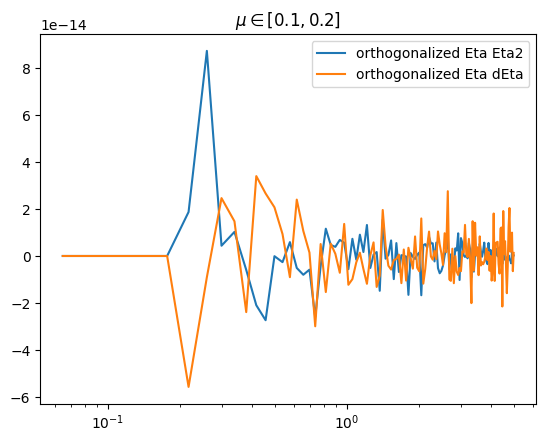

In [18]:
i_mu = 1
i_field = 5

mu = idx_to_mu[i_mu]
field_i = idx_to_ortho_fields[i_field]
for j_field in range(i_field+1, len(orthogonalized_fields)):
    field_j = idx_to_ortho_fields[j_field]
    plt.plot(k_arr, 
             rij[i_mu, i_field, j_field,:],
             label=f'orthogonalized {field_i} {field_j}')

plt.title(mu)
plt.legend()
plt.xscale('log')
#plt.yscale('log')

### Plot auto-power spectra of the orthogonalized fields

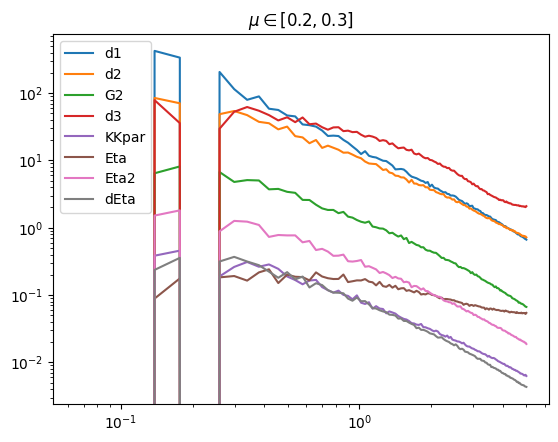

In [11]:
i_mu = 2
mu = idx_to_mu[i_mu]

k_arr, pks_auto_ortho, Nmodes = PT_field.compute_pks_2d(orthogonalized_fields, mu_edges, measure_pk=measure_pk_E)

for i_field in range(len(orthogonalized_fields)):
    field = idx_to_ortho_fields[i_field]
    plt.plot(k_arr, pks_auto_ortho[i_field,:,i_mu], label=f'{field}')

plt.title(mu)
plt.legend()
plt.xscale('log')
plt.yscale('log')

### compute $\beta_i(k, \mu)$ and get the final PT fields

In [12]:
beta_tab = model.get_beta(lya_k, orthogonalized_fields, 
                          mu_edges, measure_pk=measure_pk_E)

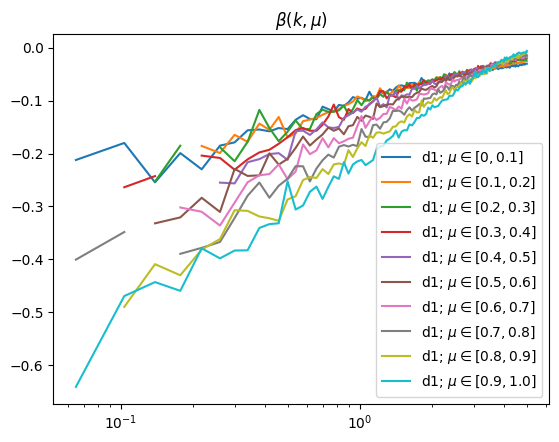

In [13]:
i_field = 0
field = idx_to_ortho_fields[i_field]

for i_mu in range(len(mu_edges)-1):
    mu = idx_to_mu[i_mu]
    plt.plot(k_arr, beta_tab[i_field,:,i_mu], 
             label=f'{field}; {mu}')

plt.title(r'$\beta(k,\mu)$')
plt.legend()
plt.xscale('log')

In [14]:
delta_g_k_linear = model.get_final_field(orthogonalized_fields[0,None],
                                         beta_tab[0,None],
                                         k_edges=k_edges, mu_edges=mu_edges,)

delta_g_k_cubic = model.get_final_field(orthogonalized_fields,
                                        beta_tab,
                                        k_edges=k_edges, mu_edges=mu_edges,)

fields = jnp.stack([lya_k, 
                    delta_g_k_linear, 
                    delta_g_k_cubic,
                    lya_k - delta_g_k_linear,
                    lya_k - delta_g_k_cubic
                    ], 
                   axis=0)

idx_to_PT_fields = {0:'LyA', 1:'linear', 2:'cubic', 3:'err; linear', 4:'err; cubic'}

k_arr, pks_auto_PT, Nmodes = PT_field.compute_pks_2d(fields, mu_edges, measure_pk=measure_pk_E)


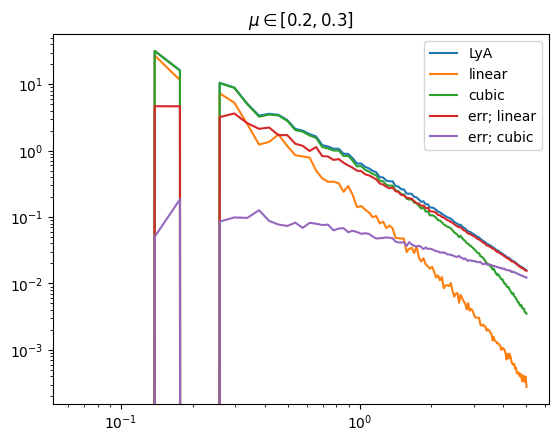

In [15]:
i_mu = 2
mu = idx_to_mu[i_mu]

for i_field in range(len(fields)):
    field = idx_to_PT_fields[i_field]
    plt.plot(k_arr, pks_auto_PT[i_field,:,i_mu], label=f'{field}')

plt.title(mu)
plt.legend()
plt.xscale('log')
plt.yscale('log')

### Save files

In [ ]:
root_save = '/home/akitsukz/works/LyA_field/sherwood/non_ortho/roger_ordering/dmu_0.1'

idx_to_ortho_fields = {0:'d1', 1:'d2', 2:'G2', 3:'d3', 4:'KKpar', 5:'Eta', 6:'Eta2', 7:'dEta',}

for i_mu in range(len(mu_edges)-1):
    mu_min = mu_edges[i_mu]
    mu_max = mu_edges[i_mu+1]
    np.savetxt(f'{root_save}/160_{ng}_thinkbin_perr_mu{mu_min}_{mu_max}.dat', 
               np.array([k_arr, pks_auto_PT[i_field,:,i_mu]]).T
               )
    for i_field in range(len(orthogonalized_fields)):
        field = idx_to_ortho_fields[i_field]
        np.savetxt(f'{root_save}/160_{ng}_thinkbin_beta_{field}_mu{mu_min}_{mu_max}.dat', 
                   np.array([k_arr, beta_tab[i_field,:,i_mu]]).T
                   )

In [17]:
k_arr, pk_matrix, Nmodes = PT_field.compute_pks_2d(lya_fields, mu_edges, measure_pk=measure_pk_E, cross=True)

np.save(f'{root_save}/160_{ng}_thinkbin_lya_full_fields_pk_matrix', pk_matrix)